In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from scipy.stats.qmc import Sobol

In [3]:
# =========================
# 0) CONFIG (F4) — Week 04
# =========================

FN = "F4"
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ----- Paths (course repo structure) -----
INPUTS_PATH = "data/F4/initial_inputs.npy"
OUTPUTS_PATH = "data/F4/initial_outputs.npy"

# Fallback paths (for Colab / sandbox testing)
FALLBACK_INPUTS = "/mnt/data/initial_inputs.npy"
FALLBACK_OUTPUTS = "/mnt/data/initial_outputs.npy"

# ----- Problem bounds (scaled) -----
BOUNDS = np.array([
    [0.0, 1.0],  # x1
    [0.0, 1.0],  # x2
    [0.0, 1.0],  # x3
    [0.0, 1.0],  # x4
])

# ----- Surrogate / BO parameters -----
N_ENSEMBLE = 20
N_CAND = 8192

KAPPA = 2.2                  # slightly more exploitative than W03
DIVERSITY_LAMBDA = 0.10
R_DIVERSITY = 0.10

TOPK = 10


In [4]:
# =========================
# 1) LOAD DATA
# =========================

in_path = INPUTS_PATH if os.path.exists(INPUTS_PATH) else FALLBACK_INPUTS
out_path = OUTPUTS_PATH if os.path.exists(OUTPUTS_PATH) else FALLBACK_OUTPUTS

X = np.load(in_path)
y = np.load(out_path).ravel()

print(f"{FN} data loaded")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("y min / max:", y.min(), y.max())
print("Last evaluated point:", np.round(X[-1], 6), "→ y =", float(y[-1]))

F4 data loaded
X shape: (32, 4)
y shape: (32,)
y min / max: -46.39338781605223 0.5802719111663213
Last evaluated point: [0.973744 0.941398 0.857228 0.989443] → y = -46.39338781605223


In [5]:
# =========================
# 2) SURROGATE MODEL (ENSEMBLE)
# =========================

models = []

for seed in range(N_ENSEMBLE):
    m = ExtraTreesRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=RANDOM_SEED + seed,
        n_jobs=-1
    )
    m.fit(X, y)
    models.append(m)

def ensemble_predict(models, Xp):
    preds = np.column_stack([m.predict(Xp) for m in models])
    mu = preds.mean(axis=1)
    sigma = preds.std(axis=1) + 1e-8  # numerical floor
    return mu, sigma

# Training diagnostics
mu_train, _ = ensemble_predict(models, X)

In [6]:
# =========================
# 3) ACQUISITION: UCB + DIVERSITY PENALTY
# =========================

d = X.shape[1]

sampler = Sobol(d=d, scramble=True, seed=RANDOM_SEED)
m = int(np.ceil(np.log2(N_CAND)))
Xcand = sampler.random_base2(m=m)[:N_CAND]

# Clip to bounds
for j in range(d):
    Xcand[:, j] = np.clip(Xcand[:, j], BOUNDS[j, 0], BOUNDS[j, 1])

mu, sigma = ensemble_predict(models, Xcand)

# UCB
ucb = mu + KAPPA * sigma

# Diversity penalty
d2 = ((Xcand[:, None, :] - X[None, :, :]) ** 2).sum(axis=2)
min_d2 = d2.min(axis=1)
min_dist = np.sqrt(min_d2)

penalty = DIVERSITY_LAMBDA * np.exp(-min_d2 / (2 * R_DIVERSITY ** 2))
score = ucb - penalty

best_idx = int(np.argmax(score))
x_next = Xcand[best_idx]

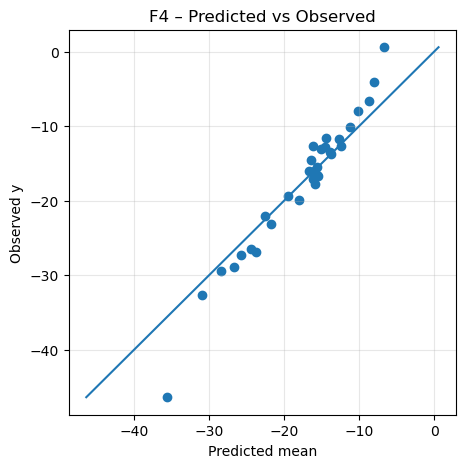

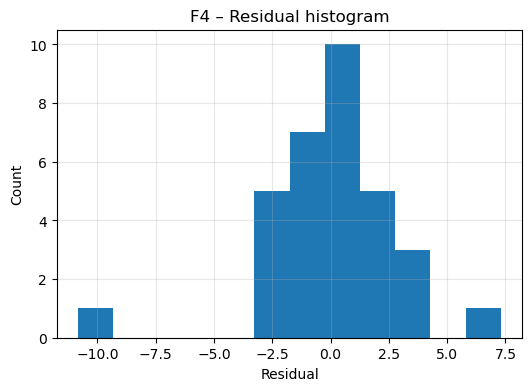

,feature,importance
1,x2,0.299948
0,x1,0.287805
3,x4,0.276769
2,x3,0.135478


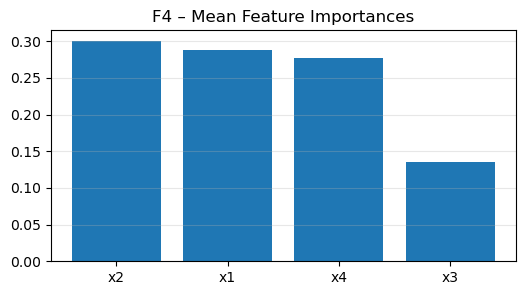

Min distance to existing data: 0.10376405688591364


In [7]:
# =========================
# 4) DIAGNOSTICS
# =========================

# Predicted vs observed
plt.figure(figsize=(5,5))
plt.scatter(mu_train, y)
lo = min(mu_train.min(), y.min())
hi = max(mu_train.max(), y.max())
plt.plot([lo, hi], [lo, hi])
plt.xlabel("Predicted mean")
plt.ylabel("Observed y")
plt.title("F4 – Predicted vs Observed")
plt.grid(True, alpha=0.3)
plt.show()

# Residuals
resid = y - mu_train
plt.figure(figsize=(6,4))
plt.hist(resid, bins=12)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("F4 – Residual histogram")
plt.grid(True, alpha=0.3)
plt.show()

# Feature importances (ensemble mean)
fi = np.vstack([m.feature_importances_ for m in models]).mean(axis=0)
fi_df = pd.DataFrame({
    "feature": [f"x{i+1}" for i in range(d)],
    "importance": fi
}).sort_values("importance", ascending=False)

display(fi_df)

plt.figure(figsize=(6,3))
plt.bar(fi_df["feature"], fi_df["importance"])
plt.title("F4 – Mean Feature Importances")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# Distance sanity check
min_dist_next = np.sqrt(((X - x_next) ** 2).sum(axis=1)).min()
print("Min distance to existing data:", min_dist_next)


In [8]:
# =========================
# 5) OUTPUT (ONE ROW TO SUBMIT)
# =========================

print("=== RECOMMENDED NEXT X (submit ONE row) ===")
print(x_next)
print("Rounded (6 dp):", np.round(x_next, 6))

# Backup candidates
top_idx = np.argsort(score)[-TOPK:][::-1]
backup = np.round(Xcand[top_idx], 6)

print("\nTop backup candidates:")
print(backup)


=== RECOMMENDED NEXT X (submit ONE row) ===
[0.39805033 0.43419797 0.4073005  0.31627846]
Rounded (6 dp): [0.39805  0.434198 0.4073   0.316278]

Top backup candidates:
[[0.39805  0.434198 0.4073   0.316278]
 [0.415091 0.447439 0.379873 0.420895]
 [0.350888 0.440084 0.404003 0.281112]
 [0.469464 0.409841 0.365454 0.389347]
 [0.424395 0.399481 0.400456 0.170101]
 [0.295874 0.417135 0.358849 0.312089]
 [0.337739 0.425867 0.430042 0.487283]
 [0.429827 0.416015 0.440619 0.034307]
 [0.449829 0.33783  0.425977 0.362866]
 [0.314702 0.475749 0.412783 0.236494]]
